# 04 — Explicabilidad, análisis de errores y métricas de negocio

## Predicción del riesgo de rotura de stock en un entorno logístico

Este notebook completa la evaluación del modelo seleccionado en el notebook 03 y cubre las tres últimas fases exigidas por el proyecto:

1. **Interpretar el modelo** mediante importancia nativa, importancia por permutación y SHAP cuando sea compatible.
2. **Traducir las predicciones a decisiones de negocio** mediante umbrales, escenarios económicos y priorización por capacidad operativa.
3. **Explicar una posible puesta en producción** mediante un proceso batch, monitorización y versionado.

> **Limitación central:** el target de riesgo es una aproximación construida con las variables disponibles. Por tanto, las conclusiones demuestran una metodología de trabajo, pero no prueban una rotura de stock real ni un ahorro económico real.


## 1. Objetivos y preguntas de análisis

Este notebook responde a las siguientes preguntas del enunciado:

- ¿Qué variables influyen más en las predicciones?
- ¿Qué información aportan las técnicas de explicabilidad?
- ¿En qué casos se equivoca el modelo?
- ¿Qué umbral ofrece el mejor equilibrio técnico y operativo?
- ¿Qué valor potencial tendría revisar las alertas generadas?
- ¿Qué ocurre si el equipo solo puede revisar el top N % de casos?
- ¿Cómo se ejecutaría, monitorizaría y actualizaría el modelo en producción?

La prioridad no es maximizar una única métrica, sino convertir probabilidades en una política de revisión comprensible y defendible.


## 2. Importación de librerías y configuración

Se utilizan métricas de clasificación, explicabilidad por permutación y visualizaciones con Matplotlib. SHAP se trata como dependencia opcional para que el notebook pueda finalizar aunque la librería no esté instalada o el pipeline no sea compatible.


In [1]:
from pathlib import Path
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42

## 3. Rutas reproducibles y validación de artefactos

El notebook depende de los artefactos generados en el notebook 03: modelo seleccionado, lista de variables y predicciones del conjunto de test. Se validan antes de continuar para evitar evaluar otro periodo o reconstruir una partición diferente.


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "models").exists():
            return candidate
    return start.parent if start.name == "notebooks" else start

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "stockout_dataset.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "best_stockout_model.pkl"
FEATURES_PATH = PROJECT_ROOT / "models" / "model_features.json"
MODEL_METADATA_PATH = PROJECT_ROOT / "models" / "model_metadata.json"

PREDICTION_CANDIDATES = [
    PROJECT_ROOT / "outputs" / "predictions" / "test_predictions_best_model.csv",
    PROJECT_ROOT / "outputs" / "test_predictions_best_model.csv",
]
PREDICTIONS_PATH = next((p for p in PREDICTION_CANDIDATES if p.exists()), PREDICTION_CANDIDATES[0])

OUTPUT_METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "explainability_business"
OUTPUT_REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

for folder in [OUTPUT_METRICS_DIR, OUTPUT_FIGURES_DIR, OUTPUT_REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

required_files = [DATA_PATH, MODEL_PATH, FEATURES_PATH, PREDICTIONS_PATH]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Faltan artefactos del notebook 03. Ejecuta los notebooks 01, 02 y 03 en orden.\n"
        + "\n".join(missing_files)
    )

print("Raíz del proyecto:", PROJECT_ROOT)
print("Predicciones:", PREDICTIONS_PATH)

Raíz del proyecto: C:\Users\lloro\Documents\GitHub\TFE_PROYECTO1
Predicciones: C:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\outputs\predictions\test_predictions_best_model.csv


## 4. Carga del modelo, metadatos y predicciones

El archivo de predicciones del notebook 03 actúa como **fuente de verdad** para `y_true`, `y_proba` y la composición exacta del conjunto de test.


In [3]:
model = joblib.load(MODEL_PATH)

with open(FEATURES_PATH, "r", encoding="utf-8") as file:
    model_features = json.load(file)

model_metadata = {}
if MODEL_METADATA_PATH.exists():
    with open(MODEL_METADATA_PATH, "r", encoding="utf-8") as file:
        model_metadata = json.load(file)

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
predictions = pd.read_csv(PREDICTIONS_PATH)

print("Modelo:", type(model).__name__)
print("Features:", len(model_features))
print("Dataset procesado:", df.shape)
print("Predicciones test:", predictions.shape)
display(predictions.head())

Modelo: XGBClassifier
Features: 20
Dataset procesado: (4472500, 34)
Predicciones test: (200000, 27)


,date,store_id,item_id,sales,price,promo,year,month,week,weekday,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_30,trend_7_30,rolling_price_mean_30,promo_days_last_7,lead_time_days,y_true,y_pred,y_probability,model
0,2023-01-01,store_1,item_1,41,21.3000,0,2023,1,52,6,1,41.0000,39.0000,36.0000,38.0000,46.4286,46.5714,44.5000,10.7343,1.9286,20.8740,1.0000,2,1,1,0.9999,XGBoost
1,2023-01-01,store_1,item_16,30,43.0800,0,2023,1,52,6,1,30.0000,25.0000,23.0000,33.0000,31.1429,29.8571,29.6667,5.9962,1.4762,42.2180,0.0000,3,1,1,1.0000,XGBoost
2,2023-01-01,store_1,item_20,39,15.2400,0,2023,1,52,6,1,40.0000,41.0000,42.0000,34.0000,47.0000,46.2143,43.9333,9.1799,3.0667,15.1387,0.0000,7,0,1,0.7834,XGBoost
3,2023-01-01,store_1,item_22,11,47.5900,0,2023,1,52,6,1,13.0000,21.0000,12.0000,10.0000,19.5714,19.4286,17.4667,4.5466,2.1048,46.6380,1.0000,2,1,1,1.0000,XGBoost
4,2023-01-01,store_1,item_25,33,89.2100,0,2023,1,52,6,1,23.0000,34.0000,27.0000,31.0000,39.5714,36.6429,35.3333,8.1000,4.2381,88.0207,1.0000,5,1,1,0.9994,XGBoost


## 5. Validación del archivo de predicciones

Se normalizan nombres de columnas, tipos y probabilidades. Esta validación evita errores silenciosos, especialmente probabilidades fuera de rango, etiquetas no numéricas o conjuntos con una sola clase.


In [6]:
rename_candidates = {
    "y_true": ["stockout_risk", "target", "actual", "real"],
    "y_pred": ["prediction", "predicted", "pred"],
    "y_proba": ["y_probability", "proba", "predicted_probability", "risk_probability"],
}

for canonical, alternatives in rename_candidates.items():
    if canonical not in predictions.columns:
        match = next((col for col in alternatives if col in predictions.columns), None)
        if match:
            predictions = predictions.rename(columns={match: canonical})

required_prediction_columns = {"y_true", "y_proba"}
missing = required_prediction_columns - set(predictions.columns)
if missing:
    raise ValueError(f"Faltan columnas obligatorias en las predicciones: {sorted(missing)}")

predictions["y_true"] = pd.to_numeric(predictions["y_true"], errors="raise").astype(int)
predictions["y_proba"] = pd.to_numeric(predictions["y_proba"], errors="raise")

if not predictions["y_proba"].between(0, 1).all():
    raise ValueError("`y_proba` contiene valores fuera del intervalo [0, 1].")

if "y_pred" not in predictions.columns:
    predictions["y_pred"] = (predictions["y_proba"] >= 0.50).astype(int)
else:
    predictions["y_pred"] = pd.to_numeric(predictions["y_pred"], errors="raise").astype(int)

if "date" in predictions.columns:
    predictions["date"] = pd.to_datetime(predictions["date"], errors="coerce")

if predictions["y_true"].nunique() < 2:
    raise ValueError("El conjunto de test solo contiene una clase; no permite una evaluación válida.")

print(predictions[["y_true", "y_pred", "y_proba"]].describe())

            y_true       y_pred      y_proba
count 200,000.0000 200,000.0000 200,000.0000
mean        0.8484       0.8383       0.8468
std         0.3586       0.3681       0.3025
min         0.0000       0.0000       0.0035
25%         1.0000       1.0000       0.9527
50%         1.0000       1.0000       0.9999
75%         1.0000       1.0000       0.9999
max         1.0000       1.0000       1.0000


## 6. Evaluación técnica final con umbral 0,50

El umbral 0,50 se utiliza como referencia inicial, no como decisión operativa definitiva.

Las métricas principales son:

- **Recall:** proporción de casos positivos detectados. Es relevante porque un falso negativo representa un riesgo no priorizado.
- **Precision:** proporción de alertas que coinciden con la clase positiva del target.
- **F1:** equilibrio entre precision y recall.
- **PR-AUC:** calidad del ranking de probabilidades sobre la clase positiva.
- **ROC-AUC:** capacidad general de discriminación entre clases.


In [7]:
y_true = predictions["y_true"].to_numpy()
y_proba = predictions["y_proba"].to_numpy()
y_pred_050 = (y_proba >= 0.50).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred_050, labels=[0, 1]).ravel()

final_metrics = {
    "threshold": 0.50,
    "accuracy": accuracy_score(y_true, y_pred_050),
    "precision": precision_score(y_true, y_pred_050, zero_division=0),
    "recall": recall_score(y_true, y_pred_050, zero_division=0),
    "f1_score": f1_score(y_true, y_pred_050, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_proba),
    "pr_auc": average_precision_score(y_true, y_proba),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
    "alerts_generated": int(tp + fp),
    "alert_rate": float((tp + fp) / len(y_true)),
}

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.to_csv(OUTPUT_METRICS_DIR / "final_model_metrics.csv", index=False)
display(final_metrics_df)
print(classification_report(y_true, y_pred_050, zero_division=0))

,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,tn,fp,fn,tp,alerts_generated,alert_rate
0,0.5000,0.9458,0.9737,0.9621,0.9678,0.9842,0.9973,25903,4416,6430,163251,167667,0.8383


              precision    recall  f1-score   support

           0       0.80      0.85      0.83     30319
           1       0.97      0.96      0.97    169681

    accuracy                           0.95    200000
   macro avg       0.89      0.91      0.90    200000
weighted avg       0.95      0.95      0.95    200000



### 6.1 Matriz de confusión

La matriz permite traducir las métricas a volúmenes operativos: alertas correctas, falsas alertas y riesgos no detectados.


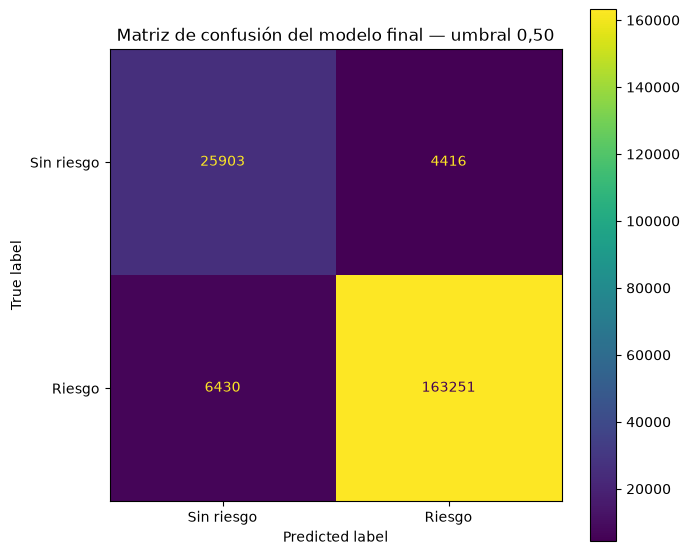

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Sin riesgo", "Riesgo"],
).plot(ax=ax, values_format="d")
ax.set_title("Matriz de confusión del modelo final — umbral 0,50")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "confusion_matrix_threshold_050.png", dpi=160, bbox_inches="tight")
plt.show()

### 6.2 Curvas ROC y Precision-Recall

Estas curvas muestran el comportamiento del modelo para todos los umbrales. La curva Precision-Recall resulta especialmente útil porque se centra en la calidad de la detección de la clase positiva.


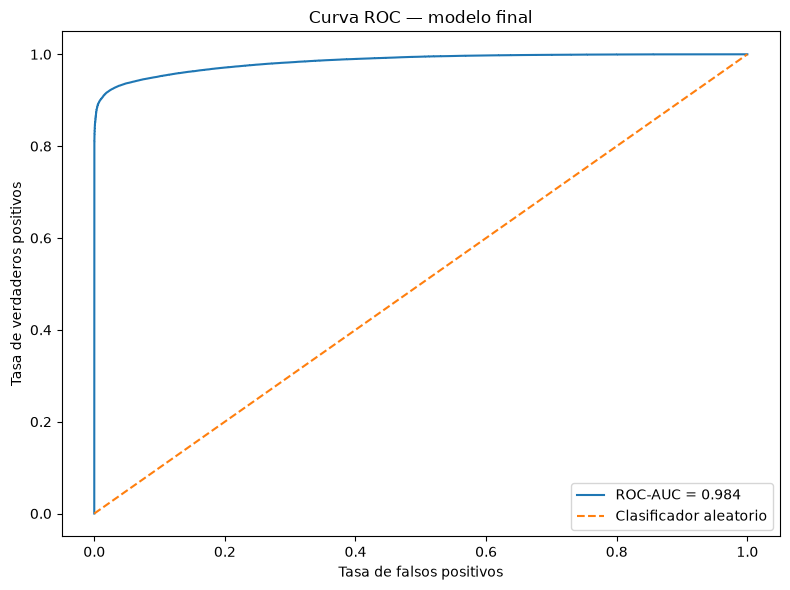

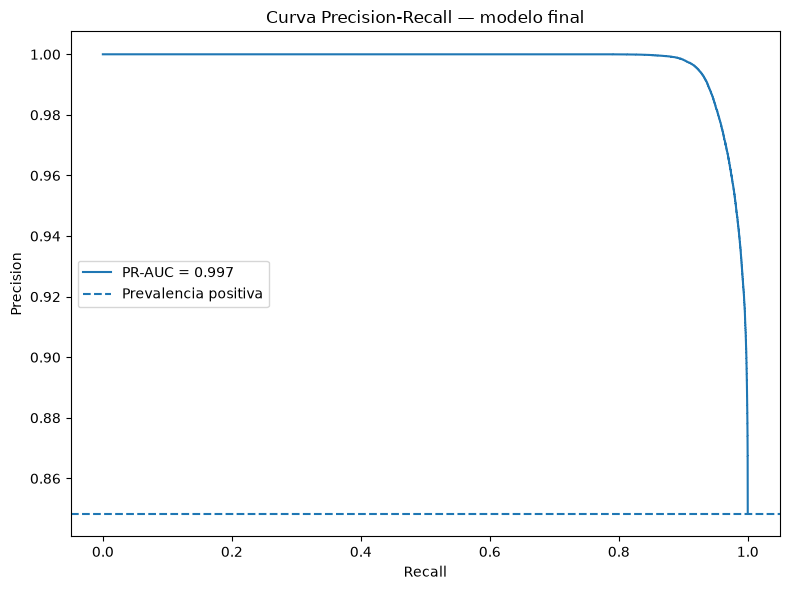

In [9]:
fpr, tpr, _ = roc_curve(y_true, y_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {final_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — modelo final")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "final_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {final_metrics['pr_auc']:.3f}")
plt.axhline(y=np.mean(y_true), linestyle="--", label="Prevalencia positiva")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — modelo final")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "final_precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Reconstrucción exacta de `X_test`

Para explicar el modelo se necesitan las mismas variables utilizadas al generar las predicciones. Primero se reutilizan las columnas ya presentes en el archivo de predicciones y, si falta alguna, se recupera del dataset procesado mediante las claves disponibles.

No se vuelve a dividir el dataset ni se calcula otro percentil temporal, porque eso podría producir una muestra distinta de la evaluada en el notebook 03.


In [10]:
# Compruebo qué variables del modelo ya están disponibles en el archivo de predicciones.
features_in_predictions = [
    feature
    for feature in model_features
    if feature in predictions.columns
]

# Identifico únicamente las variables que necesito recuperar del dataset procesado.
missing_features = [
    feature
    for feature in model_features
    if feature not in predictions.columns
]

print(f"Features ya disponibles en predictions: {len(features_in_predictions)}")
print(f"Features que necesito recuperar: {len(missing_features)}")

# Empiezo con una copia para no modificar el DataFrame original de predicciones.
enriched = predictions.copy()

if missing_features:
    join_keys = [
        key
        for key in ["date", "store_id", "item_id"]
        if key in predictions.columns and key in df.columns
    ]

    if not join_keys:
        raise ValueError(
            "No es posible reconstruir X_test porque las predicciones "
            "no contienen claves comunes con el dataset procesado."
        )

    # Compruebo que las features pendientes existan en el dataset procesado.
    unavailable_features = [
        feature
        for feature in missing_features
        if feature not in df.columns
    ]

    if unavailable_features:
        raise ValueError(
            "El dataset procesado no contiene estas features: "
            f"{unavailable_features}"
        )

    duplicated_lookup = df.duplicated(join_keys).sum()

    if duplicated_lookup:
        raise ValueError(
            f"El dataset tiene {duplicated_lookup} duplicados "
            f"para las claves {join_keys}."
        )

    # Solo incorporo las features que todavía no existen en predictions.
    lookup_columns = join_keys + missing_features

    enriched = predictions.merge(
        df[lookup_columns],
        on=join_keys,
        how="left",
        validate="many_to_one"
    )

# Verifico que después del proceso estén disponibles todas las features.
still_missing = [
    feature
    for feature in model_features
    if feature not in enriched.columns
]

if still_missing:
    raise ValueError(
        "No se pudieron recuperar estas features: "
        f"{still_missing}"
    )

# Compruebo si alguna predicción no encontró correspondencia en el dataset.
rows_with_missing_features = enriched[model_features].isna().any(axis=1)

if rows_with_missing_features.any():
    missing_rows = int(rows_with_missing_features.sum())

    raise ValueError(
        f"No se pudieron recuperar todas las features para "
        f"{missing_rows} predicciones."
    )

# Construyo el conjunto de test que utilizaré para la explicabilidad.
X_test = enriched[model_features].copy()

print("X_test reconstruido:", X_test.shape)

Features ya disponibles en predictions: 20
Features que necesito recuperar: 0
X_test reconstruido: (200000, 20)


## 8. Explicabilidad global

Se adopta una estrategia escalonada:

1. **Importancia nativa**, cuando el estimador expone coeficientes o `feature_importances_`.
2. **Importancia por permutación**, aplicable al pipeline completo y medida sobre PR-AUC.
3. **SHAP**, cuando la librería y el modelo son compatibles.

Estas técnicas describen cómo utiliza el modelo las variables; no demuestran relaciones causales.


### 8.1 Importancia nativa

En modelos de árboles se utilizan las importancias internas. En regresión logística se usa el valor absoluto de los coeficientes, ya que el signo y la escala requieren una interpretación adicional.


In [11]:
def get_final_estimator(fitted_model):
    if hasattr(fitted_model, "named_steps"):
        return list(fitted_model.named_steps.values())[-1]
    return fitted_model

estimator = get_final_estimator(model)
native_importance = None
importance_type = None

if hasattr(estimator, "feature_importances_"):
    native_importance = np.asarray(estimator.feature_importances_)
    importance_type = "feature_importances"
elif hasattr(estimator, "coef_"):
    coef = np.asarray(estimator.coef_)
    native_importance = np.abs(coef[0] if coef.ndim > 1 else coef)
    importance_type = "absolute_coefficient"

if native_importance is not None and len(native_importance) == len(model_features):
    native_importance_df = (
        pd.DataFrame({"feature": model_features, "importance": native_importance})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    native_importance_df["importance_type"] = importance_type
    native_importance_df.to_csv(OUTPUT_METRICS_DIR / "native_feature_importance.csv", index=False)
    display(native_importance_df.head(15))
else:
    native_importance_df = pd.DataFrame()
    print("El modelo no expone una importancia nativa directamente comparable.")

,feature,importance,importance_type
0,lead_time_days,0.8165,feature_importances
1,week,0.0618,feature_importances
2,month,0.0381,feature_importances
3,promo_days_last_7,0.0166,feature_importances
4,trend_7_30,0.0136,feature_importances
5,rolling_std_30,0.0081,feature_importances
6,rolling_mean_7,0.0065,feature_importances
7,sales,0.0064,feature_importances
8,rolling_mean_14,0.0054,feature_importances
9,rolling_mean_30,0.0052,feature_importances


### 8.2 Importancia por permutación

Cada variable se desordena de forma controlada y se mide cuánto disminuye la PR-AUC. Una caída mayor indica que el modelo depende más de esa variable.

Para limitar memoria y tiempo de ejecución se emplea una muestra reproducible, tres repeticiones y un único núcleo.


In [12]:
# Para evitar problemas de memoria, utilizo una muestra más pequeña
# y ejecuto el cálculo con un solo núcleo.

sample_n = min(2000, len(X_test))

X_perm = X_test.sample(
    n=sample_n,
    random_state=RANDOM_STATE
)

y_perm = y_true[X_perm.index]

permutation_result = permutation_importance(
    model,
    X_perm,
    y_perm,
    scoring="average_precision",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1
)

permutation_importance_df = pd.DataFrame({
    "feature": model_features,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

permutation_importance_df.to_csv(
    OUTPUT_METRICS_DIR / "permutation_feature_importance.csv",
    index=False
)

display(permutation_importance_df.head(15))

,feature,importance_mean,importance_std
0,lead_time_days,0.1280,0.0079
1,week,0.0024,0.0001
2,rolling_std_30,0.0012,0.0001
3,promo_days_last_7,0.0005,0.0001
4,trend_7_30,0.0003,0.0001
5,rolling_mean_7,0.0002,0.0001
6,rolling_mean_14,0.0001,0.0001
7,sales,0.0001,0.0001
8,month,0.0001,0.0000
9,weekday,0.0001,0.0000


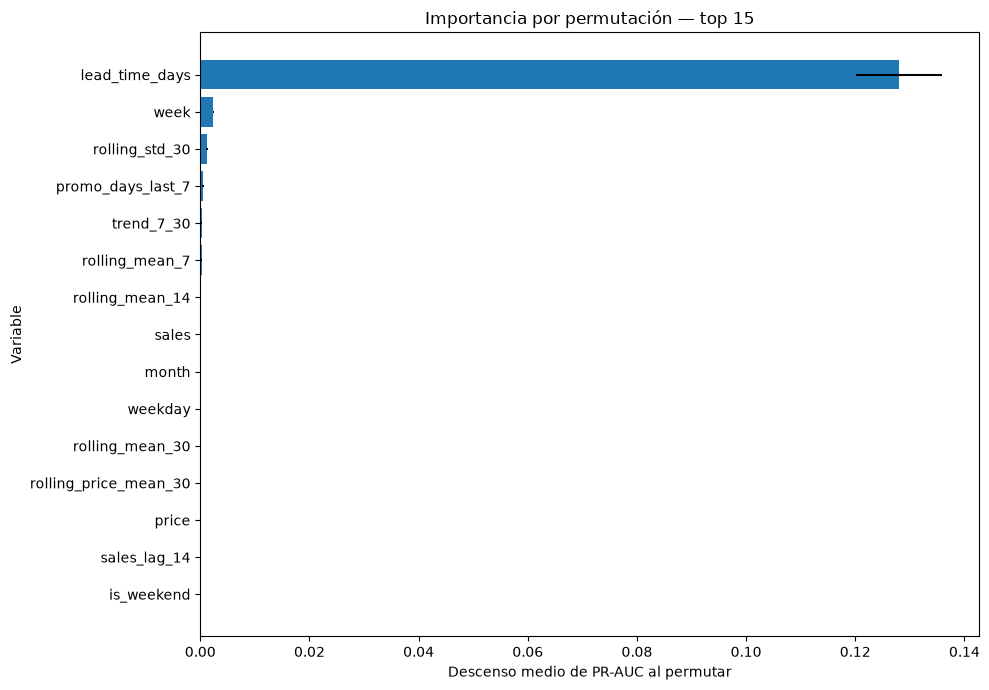

In [14]:
plot_df = permutation_importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.xlabel("Descenso medio de PR-AUC al permutar")
plt.ylabel("Variable")
plt.title("Importancia por permutación — top 15")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "permutation_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

### 8.3 Explicabilidad con SHAP

SHAP permite observar tanto la relevancia global como la contribución de las variables a las predicciones. Su ejecución es opcional porque no todos los pipelines y versiones de librerías son compatibles.

Si SHAP falla, el notebook conserva como explicaciones válidas la importancia nativa y la importancia por permutación, y registra el motivo del fallo.


In [15]:
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP no está instalado. Instálalo con: python -m pip install shap")

Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.


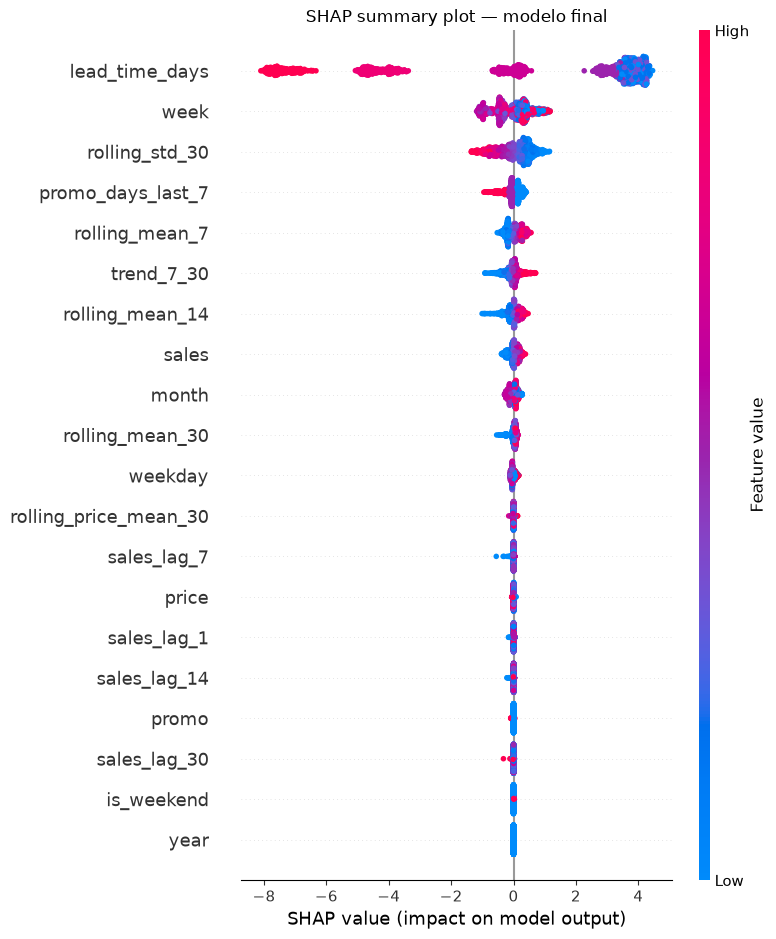

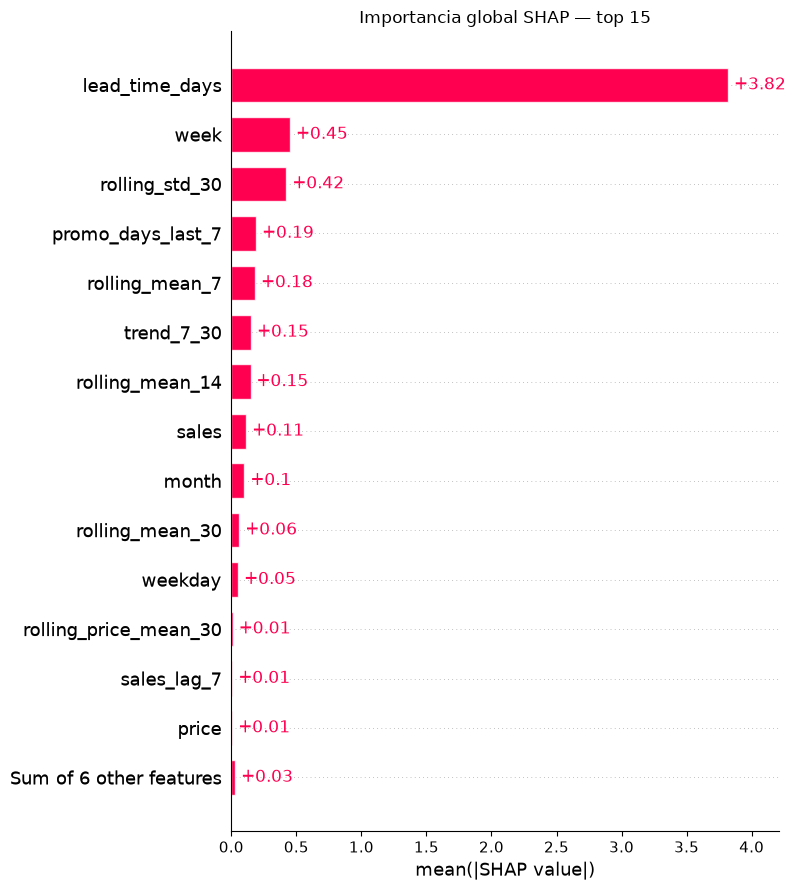

In [16]:
shap_status = {"executed": False, "method": None, "error": None}

if SHAP_AVAILABLE:
    shap_sample_n = min(2000, len(X_test))
    X_shap = X_test.sample(shap_sample_n, random_state=RANDOM_STATE)

    try:
        # Para pipelines, SHAP se aplica sobre la matriz transformada y el estimador final.
        if hasattr(model, "named_steps") and len(model.named_steps) > 1:
            preprocessing_steps = list(model.named_steps.items())[:-1]
            transformed = X_shap.copy()
            for _, step in preprocessing_steps:
                transformed = step.transform(transformed)
            X_shap_for_explainer = transformed
            shap_feature_names = model_features
            shap_estimator = estimator
        else:
            X_shap_for_explainer = X_shap
            shap_feature_names = model_features
            shap_estimator = model

        explainer = shap.Explainer(shap_estimator, X_shap_for_explainer)
        shap_values = explainer(X_shap_for_explainer)

        shap.summary_plot(
            shap_values,
            X_shap_for_explainer,
            feature_names=shap_feature_names,
            show=False,
        )
        plt.title("SHAP summary plot — modelo final")
        plt.tight_layout()
        plt.savefig(OUTPUT_FIGURES_DIR / "shap_summary_plot.png", dpi=160, bbox_inches="tight")
        plt.show()

        shap.plots.bar(shap_values, max_display=15, show=False)
        plt.title("Importancia global SHAP — top 15")
        plt.tight_layout()
        plt.savefig(OUTPUT_FIGURES_DIR / "shap_global_bar.png", dpi=160, bbox_inches="tight")
        plt.show()

        shap_status = {"executed": True, "method": type(explainer).__name__, "error": None}

    except Exception as exc:
        shap_status = {"executed": False, "method": None, "error": str(exc)}
        print("SHAP no pudo ejecutarse con este pipeline/modelo.")
        print("La explicabilidad global queda cubierta mediante importancia nativa y permutación.")
        print("Detalle:", exc)

with open(OUTPUT_REPORTS_DIR / "shap_execution_status.json", "w", encoding="utf-8") as file:
    json.dump(shap_status, file, indent=2, ensure_ascii=False)

## 9. Análisis de errores

Los resultados se clasifican en:

- **TP:** riesgo identificado correctamente según el target.
- **FP:** alerta que no coincide con el target.
- **FN:** riesgo que el modelo no detecta.
- **TN:** caso sin riesgo clasificado correctamente.

El objetivo es detectar patrones de fallo y segmentos que requieran revisión, no limitarse a una métrica agregada.


In [17]:
analysis_df = predictions.copy()
analysis_df["y_pred_050"] = y_pred_050
analysis_df["error_type"] = np.select(
    [
        (analysis_df["y_true"] == 1) & (analysis_df["y_pred_050"] == 1),
        (analysis_df["y_true"] == 0) & (analysis_df["y_pred_050"] == 1),
        (analysis_df["y_true"] == 1) & (analysis_df["y_pred_050"] == 0),
        (analysis_df["y_true"] == 0) & (analysis_df["y_pred_050"] == 0),
    ],
    ["TP", "FP", "FN", "TN"],
    default="UNKNOWN",
)

error_summary = (
    analysis_df.groupby("error_type", observed=True)
    .agg(cases=("y_true", "size"), mean_probability=("y_proba", "mean"))
    .reset_index()
)
error_summary["percentage"] = error_summary["cases"] / len(analysis_df)
error_summary.to_csv(OUTPUT_METRICS_DIR / "error_type_summary.csv", index=False)
display(error_summary)

,error_type,cases,mean_probability,percentage
0,FN,6430,0.3245,0.0321
1,FP,4416,0.6706,0.0221
2,TN,25903,0.1676,0.1295
3,TP,163251,0.9799,0.8163


### 9.1 Errores por segmento

Cuando las columnas están disponibles, se comparan tiendas, productos, periodos, promociones y lead time. Los ratios se interpretan junto con el número de casos, ya que los segmentos pequeños pueden generar resultados inestables.


In [18]:
segment_columns = [col for col in ["store_id", "item_id", "year", "month", "promo", "lead_time_days"] if col in analysis_df.columns]

segment_reports = []
for column in segment_columns:
    report = (
        analysis_df.groupby(column, dropna=False, observed=True)
        .agg(
            cases=("y_true", "size"),
            actual_positive_rate=("y_true", "mean"),
            predicted_positive_rate=("y_pred_050", "mean"),
            mean_probability=("y_proba", "mean"),
        )
        .reset_index()
    )
    report["false_negative_rate"] = (
        analysis_df.assign(is_fn=(analysis_df["error_type"] == "FN").astype(int))
        .groupby(column, dropna=False, observed=True)["is_fn"].mean()
        .reindex(report[column])
        .to_numpy()
    )
    report["false_positive_rate"] = (
        analysis_df.assign(is_fp=(analysis_df["error_type"] == "FP").astype(int))
        .groupby(column, dropna=False, observed=True)["is_fp"].mean()
        .reindex(report[column])
        .to_numpy()
    )
    report["segment"] = column
    report = report.rename(columns={column: "segment_value"})
    segment_reports.append(report)

if segment_reports:
    segment_error_df = pd.concat(segment_reports, ignore_index=True)
    segment_error_df.to_csv(OUTPUT_METRICS_DIR / "segment_error_analysis.csv", index=False)
    display(segment_error_df.sort_values(["segment", "cases"], ascending=[True, False]).head(30))
else:
    segment_error_df = pd.DataFrame()
    print("El archivo de predicciones no contiene columnas segmentables adicionales.")

,segment_value,cases,actual_positive_rate,predicted_positive_rate,mean_probability,false_negative_rate,false_positive_rate,segment
55,item_14,4168,1.0000,1.0000,0.9999,0.0000,0.0000,item_id
60,item_19,4152,0.6305,0.6814,0.6533,0.1012,0.1520,item_id
66,item_24,4121,1.0000,1.0000,0.9999,0.0000,0.0000,item_id
78,item_35,4098,1.0000,1.0000,0.9999,0.0000,0.0000,item_id
80,item_37,4086,1.0000,1.0000,0.9999,0.0000,0.0000,item_id
63,item_21,4076,1.0000,1.0000,0.9999,0.0000,0.0000,item_id
76,item_33,4071,0.6979,0.7158,0.7046,0.0960,0.1140,item_id
71,item_29,4045,1.0000,1.0000,0.9999,0.0000,0.0000,item_id
77,item_34,4044,0.2094,0.0779,0.2063,0.1657,0.0341,item_id
95,item_50,4044,1.0000,1.0000,0.9999,0.0000,0.0000,item_id


### 9.2 Ejemplos representativos

Se exportan falsos negativos, falsos positivos y verdaderos positivos para facilitar una revisión cualitativa posterior con personal de negocio.


In [19]:
example_columns = [
    col for col in ["date", "store_id", "item_id", "y_true", "y_pred_050", "y_proba", "error_type"]
    if col in analysis_df.columns
]
error_examples = pd.concat([
    analysis_df[analysis_df["error_type"] == "FN"].sort_values("y_proba").head(10),
    analysis_df[analysis_df["error_type"] == "FP"].sort_values("y_proba", ascending=False).head(10),
    analysis_df[analysis_df["error_type"] == "TP"].sort_values("y_proba", ascending=False).head(10),
], ignore_index=True)

error_examples[example_columns].to_csv(
    OUTPUT_REPORTS_DIR / "representative_prediction_errors.csv", index=False
)
display(error_examples[example_columns].head(30))

,date,store_id,item_id,y_true,y_pred_050,y_proba,error_type
0,2023-07-21,store_5,item_6,1,0,0.0122,FN
1,2023-06-10,store_2,item_48,1,0,0.0145,FN
2,2023-08-20,store_42,item_20,1,0,0.0146,FN
3,2023-08-28,store_14,item_20,1,0,0.0168,FN
4,2023-06-19,store_17,item_13,1,0,0.0169,FN
5,2023-08-04,store_39,item_6,1,0,0.0188,FN
6,2023-07-03,store_20,item_20,1,0,0.0188,FN
7,2023-07-31,store_35,item_20,1,0,0.0189,FN
8,2023-06-24,store_19,item_27,1,0,0.0194,FN
9,2023-06-18,store_8,item_13,1,0,0.0194,FN


## 10. Selección del umbral de decisión

El umbral 0,50 no tiene por qué ser el más útil. Se prueban valores entre 0,10 y 0,90 y se mide cómo cambian:

- precision, recall y F1;
- número total de alertas;
- falsos positivos;
- falsos negativos;
- cobertura de casos positivos.

El mejor umbral por F1 es una referencia técnica. La decisión final debe considerar costes y capacidad operativa.


In [20]:
thresholds = np.round(np.arange(0.10, 0.91, 0.025), 3)
threshold_rows = []

for threshold in thresholds:
    pred = (y_proba >= threshold).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1_score": f1_score(y_true, pred, zero_division=0),
        "tn": int(tn_t),
        "fp": int(fp_t),
        "fn": int(fn_t),
        "tp": int(tp_t),
        "alerts_generated": int(tp_t + fp_t),
        "alert_rate": float((tp_t + fp_t) / len(y_true)),
        "stockout_capture_rate": float(tp_t / (tp_t + fn_t)) if (tp_t + fn_t) else 0.0,
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(OUTPUT_METRICS_DIR / "threshold_analysis.csv", index=False)

best_f1_row = threshold_df.loc[threshold_df["f1_score"].idxmax()]
display(threshold_df.head())
print("Mejor umbral por F1:", float(best_f1_row["threshold"]))

,threshold,accuracy,precision,recall,f1_score,tn,fp,fn,tp,alerts_generated,alert_rate,stockout_capture_rate
0,0.1000,0.9081,0.9043,0.9973,0.9485,12403,17916,459,169222,187138,0.9357,0.9973
1,0.1250,0.9129,0.9096,0.9965,0.9510,13506,16813,602,169079,185892,0.9295,0.9965
2,0.1500,0.9168,0.9140,0.9956,0.9531,14428,15891,740,168941,184832,0.9242,0.9956
3,0.1750,0.9203,0.9183,0.9946,0.9549,15305,15014,919,168762,183776,0.9189,0.9946
4,0.2000,0.9237,0.9226,0.9933,0.9567,16186,14133,1133,168548,182681,0.9134,0.9933


Mejor umbral por F1: 0.475


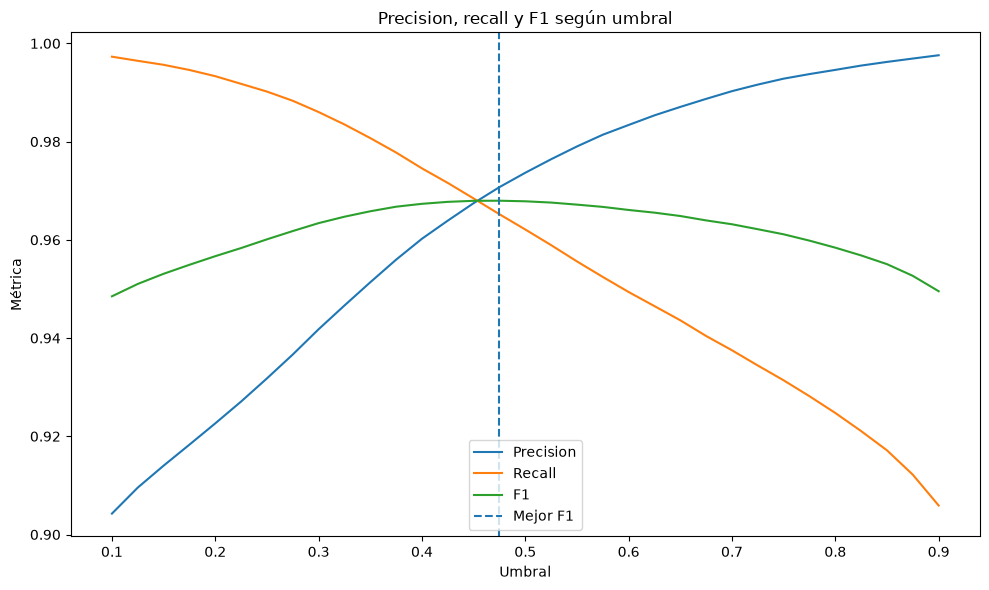

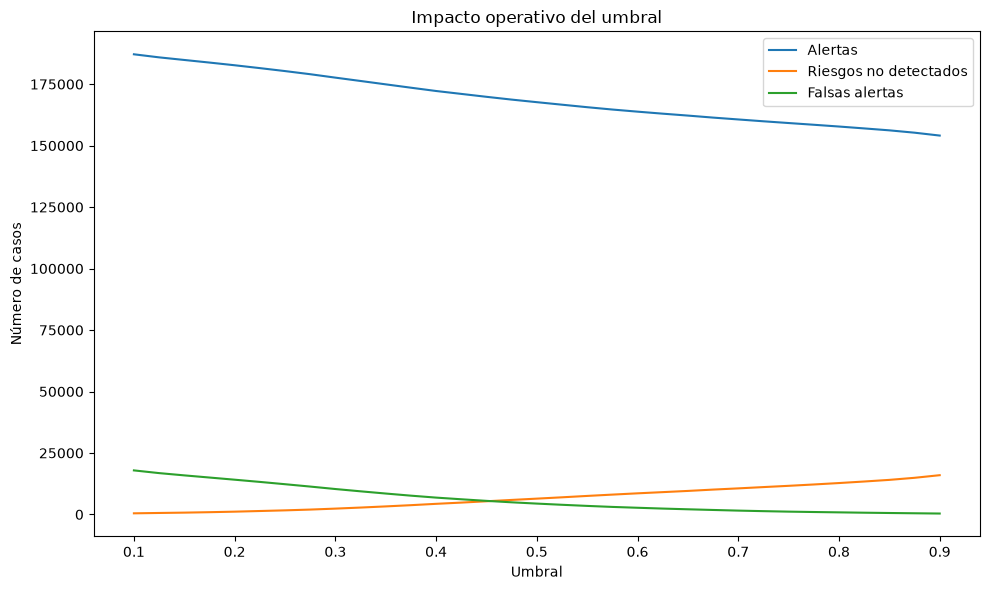

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1")
plt.axvline(float(best_f1_row["threshold"]), linestyle="--", label="Mejor F1")
plt.xlabel("Umbral")
plt.ylabel("Métrica")
plt.title("Precision, recall y F1 según umbral")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "threshold_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["alerts_generated"], label="Alertas")
plt.plot(threshold_df["threshold"], threshold_df["fn"], label="Riesgos no detectados")
plt.plot(threshold_df["threshold"], threshold_df["fp"], label="Falsas alertas")
plt.xlabel("Umbral")
plt.ylabel("Número de casos")
plt.title("Impacto operativo del umbral")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "threshold_operational_impact.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Simulación de métricas de negocio

El dataset no contiene ventas perdidas, coste de revisión ni ahorro real. Por ello se definen tres **escenarios hipotéticos y editables**:

- coste de revisar una alerta;
- pérdida asociada a un riesgo no detectado;
- porcentaje de pérdida evitable al actuar sobre una alerta correcta.

La simulación permite explicar el método para traducir la matriz de confusión a impacto económico, pero sus resultados no deben presentarse como ahorro real.


In [22]:
business_scenarios = pd.DataFrame([
    {
        "scenario": "Conservador",
        "cost_review_alert": 15.0,
        "loss_per_missed_stockout": 50.0,
        "avoidable_loss_rate": 0.30,
    },
    {
        "scenario": "Base",
        "cost_review_alert": 10.0,
        "loss_per_missed_stockout": 100.0,
        "avoidable_loss_rate": 0.60,
    },
    {
        "scenario": "Optimista",
        "cost_review_alert": 8.0,
        "loss_per_missed_stockout": 200.0,
        "avoidable_loss_rate": 0.80,
    },
])

business_rows = []
total_positives = int(np.sum(y_true))

for _, scenario in business_scenarios.iterrows():
    baseline_loss = total_positives * scenario["loss_per_missed_stockout"]

    for _, row in threshold_df.iterrows():
        review_cost = row["alerts_generated"] * scenario["cost_review_alert"]
        residual_loss_detected = (
            row["tp"]
            * scenario["loss_per_missed_stockout"]
            * (1 - scenario["avoidable_loss_rate"])
        )
        missed_loss = row["fn"] * scenario["loss_per_missed_stockout"]
        cost_with_model = review_cost + residual_loss_detected + missed_loss
        gross_avoided_loss = (
            row["tp"]
            * scenario["loss_per_missed_stockout"]
            * scenario["avoidable_loss_rate"]
        )
        net_benefit = baseline_loss - cost_with_model
        roi = net_benefit / review_cost if review_cost > 0 else np.nan

        business_rows.append({
            **scenario.to_dict(),
            "threshold": row["threshold"],
            "tp": int(row["tp"]),
            "fp": int(row["fp"]),
            "fn": int(row["fn"]),
            "alerts_generated": int(row["alerts_generated"]),
            "baseline_loss": baseline_loss,
            "gross_avoided_loss": gross_avoided_loss,
            "review_cost": review_cost,
            "cost_with_model": cost_with_model,
            "net_benefit": net_benefit,
            "roi": roi,
        })

business_df = pd.DataFrame(business_rows)
business_df.to_csv(OUTPUT_METRICS_DIR / "business_scenario_analysis.csv", index=False)

best_business_thresholds = (
    business_df.sort_values(["scenario", "net_benefit"], ascending=[True, False])
    .groupby("scenario", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
best_business_thresholds.to_csv(
    OUTPUT_METRICS_DIR / "best_business_thresholds.csv", index=False
)
display(best_business_thresholds)

,scenario,cost_review_alert,loss_per_missed_stockout,avoidable_loss_rate,threshold,tp,fp,fn,alerts_generated,baseline_loss,gross_avoided_loss,review_cost,cost_with_model,net_benefit,roi
0,Base,10.0000,100.0000,0.6000,0.1500,168941,15891,740,184832,"16,968,100.0000","10,136,460.0000","1,848,320.0000","8,679,960.0000","8,288,140.0000",4.4841
1,Conservador,15.0000,50.0000,0.3000,0.9000,153715,372,15966,154087,"8,484,050.0000","2,305,725.0000","2,311,305.0000","8,489,630.0000","-5,580.0000",-0.0024
2,Optimista,8.0000,200.0000,0.8000,0.1000,169222,17916,459,187138,"33,936,200.0000","27,075,520.0000","1,497,104.0000","8,357,784.0000","25,578,416.0000",17.0853


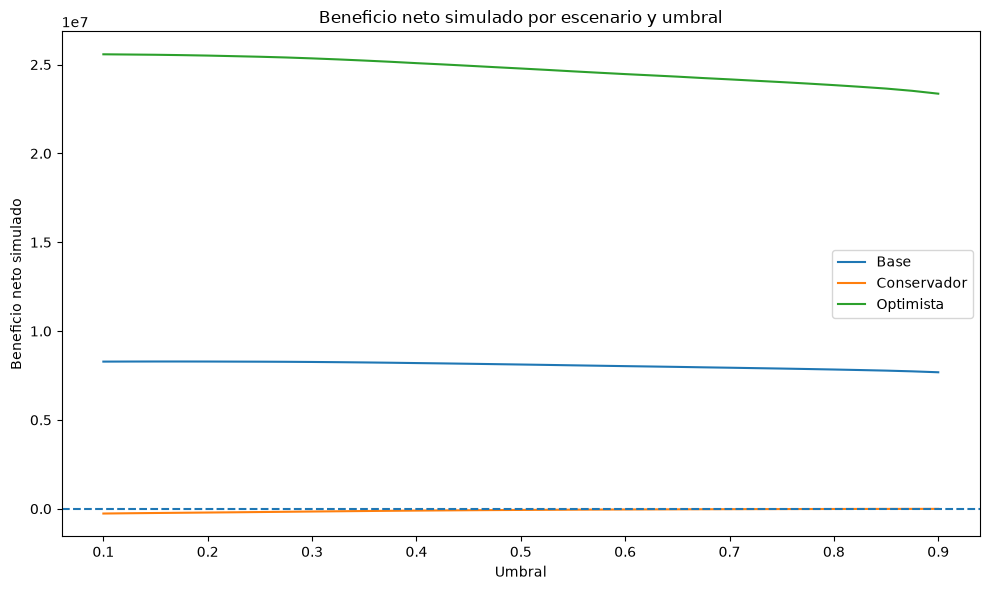

In [23]:
plt.figure(figsize=(10, 6))
for scenario, group in business_df.groupby("scenario", observed=True):
    plt.plot(group["threshold"], group["net_benefit"], label=scenario)
plt.axhline(0, linestyle="--")
plt.xlabel("Umbral")
plt.ylabel("Beneficio neto simulado")
plt.title("Beneficio neto simulado por escenario y umbral")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "business_net_benefit_by_threshold.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Priorización por capacidad operativa

En una operación real puede ser más práctico revisar un porcentaje fijo de registros ordenados por probabilidad que aplicar un umbral absoluto.

Para cada top N % se calculan:

- casos revisados;
- positivos encontrados;
- precision@k;
- recall@k;
- lift frente a una selección aleatoria.

Este análisis conecta directamente el ranking del modelo con la capacidad disponible del equipo de planificación.


In [24]:
ranked = analysis_df.sort_values("y_proba", ascending=False).reset_index(drop=True)
total_positive = int(ranked["y_true"].sum())
base_positive_rate = float(ranked["y_true"].mean())

top_percentages = [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]
priority_rows = []

for pct in top_percentages:
    n_reviewed = max(1, int(np.ceil(len(ranked) * pct)))
    selected = ranked.head(n_reviewed)
    positives_found = int(selected["y_true"].sum())
    precision_at_k = positives_found / n_reviewed
    recall_at_k = positives_found / total_positive if total_positive else 0.0
    lift = precision_at_k / base_positive_rate if base_positive_rate else np.nan

    priority_rows.append({
        "top_percentage": pct,
        "reviewed_cases": n_reviewed,
        "positives_found": positives_found,
        "precision_at_k": precision_at_k,
        "recall_at_k": recall_at_k,
        "lift_vs_random": lift,
    })

prioritization_df = pd.DataFrame(priority_rows)
prioritization_df.to_csv(OUTPUT_METRICS_DIR / "risk_prioritization.csv", index=False)
display(prioritization_df)

,top_percentage,reviewed_cases,positives_found,precision_at_k,recall_at_k,lift_vs_random
0,0.0100,2000,2000,1.0000,0.0118,1.1787
1,0.0500,10000,10000,1.0000,0.0589,1.1787
2,0.1000,20000,20000,1.0000,0.1179,1.1787
3,0.2000,40000,40000,1.0000,0.2357,1.1787
4,0.3000,60000,60000,1.0000,0.3536,1.1787
5,0.5000,100000,100000,1.0000,0.5893,1.1787


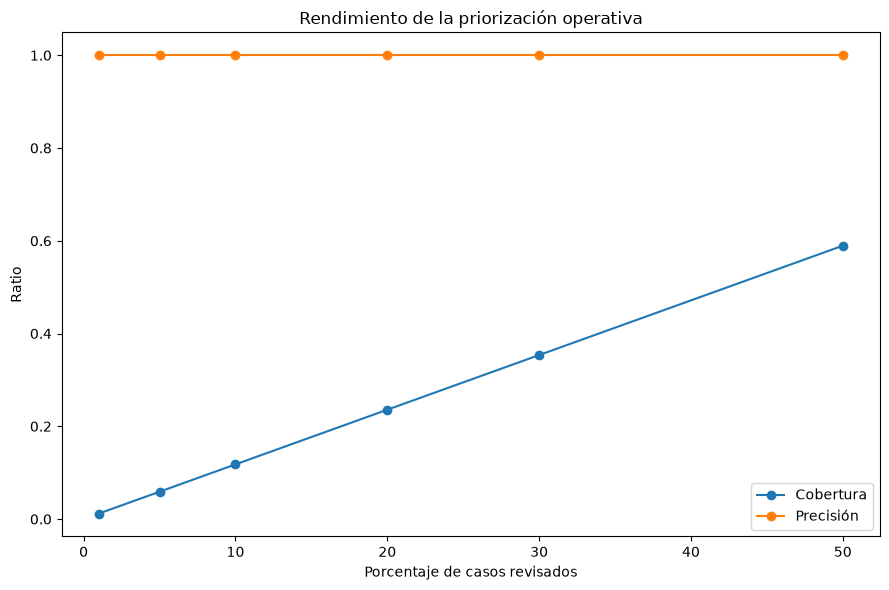

In [25]:
plt.figure(figsize=(9, 6))
plt.plot(prioritization_df["top_percentage"] * 100, prioritization_df["recall_at_k"], marker="o", label="Cobertura")
plt.plot(prioritization_df["top_percentage"] * 100, prioritization_df["precision_at_k"], marker="o", label="Precisión")
plt.xlabel("Porcentaje de casos revisados")
plt.ylabel("Ratio")
plt.title("Rendimiento de la priorización operativa")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "risk_prioritization.png", dpi=160, bbox_inches="tight")
plt.show()

## 13. Interpretación conjunta de resultados

La interpretación debe seguir estas reglas:

1. Una variable importante indica dependencia predictiva, no causalidad.
2. El target sintético limita la validez empresarial de las métricas.
3. Un umbral bajo aumenta la cobertura, pero también la carga de revisión.
4. Un umbral alto reduce alertas, pero puede dejar más riesgos sin detectar.
5. La política operativa debe validarse con responsables de planificación y con costes reales.
6. Antes de automatizar decisiones deben incorporarse inventario, pedidos abiertos, recepciones, lead time real, nivel de servicio y ventas perdidas.


## 14. Propuesta conceptual de producción

Para este caso se propone una ejecución **batch diaria**, porque la reposición y la planificación suelen trabajar con ciclos periódicos y no requieren una respuesta por milisegundos.

```text
WMS / ERP / ventas / inventario
              ↓
Validación y preparación de datos
              ↓
Generación de features históricas
              ↓
Modelo versionado
              ↓
Probabilidad por tienda-producto-fecha
              ↓
Umbral o ranking por capacidad
              ↓
Dashboard / lista de trabajo
              ↓
Decisión humana y registro del resultado
```

### Frecuencia y reentrenamiento

- Predicción: diaria.
- Revisión de calidad y distribución de predicciones: cada ejecución.
- Evaluación de rendimiento: cuando madure la etiqueta real.
- Reentrenamiento: mensual o condicionado a degradación, drift o cambios operativos.

### Actualización y versionado

Una nueva feature o modelo se probaría fuera de producción, comparándolo con la versión vigente sobre un periodo temporal posterior. Solo se promovería si mejora las métricas técnicas y de negocio sin aumentar de forma inasumible la carga operativa.

Se versionarían conjuntamente:

- código de preparación;
- definición de features;
- modelo;
- umbral operativo;
- dataset o ventana de entrenamiento;
- métricas de validación.


## 15. Plan de monitorización

La monitorización debe cubrir datos, predicciones, rendimiento, negocio y operación. No basta con comprobar que el proceso termina sin errores.


In [26]:
monitoring_plan = pd.DataFrame([
    ["Calidad de datos", "Nulos, duplicados, rangos, frecuencia temporal", "Cada ejecución", "Detener pipeline o generar alerta"],
    ["Drift de variables", "PSI, KS o divergencia por feature", "Semanal", "Investigar y valorar reentrenamiento"],
    ["Drift de predicción", "Distribución de probabilidades y tasa de alertas", "Diario", "Revisar cambios bruscos"],
    ["Rendimiento", "PR-AUC, recall, precision, F1", "Cuando madure la etiqueta", "Comparar con umbral operativo"],
    ["Negocio", "Cobertura top N, falsas alertas, incidencias evitadas", "Semanal/Mensual", "Ajustar umbral y capacidad"],
    ["Operación", "Tiempo de ejecución y fallos", "Cada ejecución", "Reintentar o escalar incidencia"],
], columns=["area", "indicator", "frequency", "action"])

monitoring_plan.to_csv(OUTPUT_REPORTS_DIR / "production_monitoring_plan.csv", index=False)
display(monitoring_plan)

,area,indicator,frequency,action
0,Calidad de datos,"Nulos, duplicados, rangos, frecuencia temporal",Cada ejecución,Detener pipeline o generar alerta
1,Drift de variables,"PSI, KS o divergencia por feature",Semanal,Investigar y valorar reentrenamiento
2,Drift de predicción,Distribución de probabilidades y tasa de alertas,Diario,Revisar cambios bruscos
3,Rendimiento,"PR-AUC, recall, precision, F1",Cuando madure la etiqueta,Comparar con umbral operativo
4,Negocio,"Cobertura top N, falsas alertas, incidencias e...",Semanal/Mensual,Ajustar umbral y capacidad
5,Operación,Tiempo de ejecución y fallos,Cada ejecución,Reintentar o escalar incidencia


## 16. Resumen ejecutivo exportable

Se genera un archivo Markdown con las métricas principales, variables relevantes, umbrales y limitaciones. Este resumen puede reutilizarse en el README del repositorio.


In [27]:
top_features = permutation_importance_df.head(5)["feature"].tolist()
base_business = best_business_thresholds[
    best_business_thresholds["scenario"] == "Base"
]
base_business = base_business.iloc[0] if not base_business.empty else None

summary_lines = [
    "# Resumen ejecutivo — explicabilidad y negocio",
    "",
    "## Rendimiento técnico",
    f"- ROC-AUC: {final_metrics['roc_auc']:.4f}",
    f"- PR-AUC: {final_metrics['pr_auc']:.4f}",
    f"- Precision con umbral 0,50: {final_metrics['precision']:.4f}",
    f"- Recall con umbral 0,50: {final_metrics['recall']:.4f}",
    f"- F1 con umbral 0,50: {final_metrics['f1_score']:.4f}",
    "",
    "## Operación con umbral 0,50",
    f"- Alertas: {final_metrics['alerts_generated']}",
    f"- Riesgos detectados: {final_metrics['tp']}",
    f"- Riesgos no detectados: {final_metrics['fn']}",
    f"- Falsas alertas: {final_metrics['fp']}",
    "",
    "## Variables más relevantes por permutación",
]
summary_lines.extend([f"- {feature}" for feature in top_features])

summary_lines.extend([
    "",
    "## Selección de umbral",
    f"- Mejor umbral técnico por F1: {float(best_f1_row['threshold']):.3f}",
])

if base_business is not None:
    summary_lines.extend([
        f"- Mejor umbral simulado en escenario base: {float(base_business['threshold']):.3f}",
        f"- Beneficio neto simulado en escenario base: {float(base_business['net_benefit']):,.2f}",
        f"- ROI simulado en escenario base: {float(base_business['roi']):.4f}",
    ])

summary_lines.extend([
    "",
    "## Limitación",
    "- El target y los costes son simulados. El proyecto demuestra metodología y valor potencial, no impacto económico real.",
    "- Antes de producción se necesitarían datos reales de inventario, pedidos, reposiciones, ventas perdidas y lead time.",
])

summary_path = OUTPUT_REPORTS_DIR / "explainability_business_summary.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print(summary_path.read_text(encoding="utf-8"))

# Resumen ejecutivo — explicabilidad y negocio

## Rendimiento técnico
- ROC-AUC: 0.9842
- PR-AUC: 0.9973
- Precision con umbral 0,50: 0.9737
- Recall con umbral 0,50: 0.9621
- F1 con umbral 0,50: 0.9678

## Operación con umbral 0,50
- Alertas: 167667
- Riesgos detectados: 163251
- Riesgos no detectados: 6430
- Falsas alertas: 4416

## Variables más relevantes por permutación
- lead_time_days
- week
- rolling_std_30
- promo_days_last_7
- trend_7_30

## Selección de umbral
- Mejor umbral técnico por F1: 0.475
- Mejor umbral simulado en escenario base: 0.150
- Beneficio neto simulado en escenario base: 8,288,140.00
- ROI simulado en escenario base: 4.4841

## Limitación
- El target y los costes son simulados. El proyecto demuestra metodología y valor potencial, no impacto económico real.
- Antes de producción se necesitarían datos reales de inventario, pedidos, reposiciones, ventas perdidas y lead time.


## 17. Conclusiones

Este notebook completa la parte de explicabilidad, métricas de negocio y propuesta de producción del proyecto.

Las conclusiones principales son:

1. El modelo debe utilizarse como **sistema de apoyo y priorización**, no como automatización autónoma de reposición.
2. La importancia por permutación ofrece una explicación global comparable sobre el pipeline completo.
3. SHAP amplía la interpretación cuando el modelo y el entorno son compatibles, pero no es imprescindible para que el análisis sea válido.
4. El umbral debe seleccionarse según el coste de falsos negativos, falsas alertas y capacidad de revisión.
5. La priorización del top N % convierte el modelo en una lista de trabajo operativa.
6. Los escenarios económicos son demostrativos porque se apoyan en supuestos, no en costes observados.
7. La principal limitación es la ausencia de una etiqueta real de rotura de stock y de variables operativas de inventario.
